In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix
)

In [2]:
INPUT_FILE = "C:/Users/oussama.nair/Downloads/outputs/london_morphological_features.csv"

print("Loading feature dataset...")

df = pd.read_csv(INPUT_FILE)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

Loading feature dataset...
Rows: 235,454
Columns: 37


In [3]:
features = [
    "min_raylen2D",
    "avg_raylen2D",
    "med_raylen2D",
    "drift_raylen2D",
    "H_raylen2D",
    "avg_raylen25D",
    "svf_geom",
    "isovist_area",
    "isovist_perimeter"
]
for col in features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[df["period"].isin(["day", "night"])].copy()

df[features].isna().sum()

min_raylen2D         0
avg_raylen2D         0
med_raylen2D         0
drift_raylen2D       0
H_raylen2D           0
avg_raylen25D        0
svf_geom             0
isovist_area         0
isovist_perimeter    0
dtype: int64

In [4]:
trajectory_features = (
    df
    .groupby(["trace_id", "period"])[features]
    .agg(["mean", "median", "std", "min", "max"])
)

trajectory_features.columns = [
    f"{feature}_{stat}"
    for feature, stat in trajectory_features.columns
]

trajectory_features = trajectory_features.reset_index()

trajectory_features.shape

(5217, 47)

In [5]:
trajectory_features.head()

,trace_id,period,min_raylen2D_mean,min_raylen2D_median,min_raylen2D_std,min_raylen2D_min,min_raylen2D_max,avg_raylen2D_mean,avg_raylen2D_median,avg_raylen2D_std,...,isovist_area_mean,isovist_area_median,isovist_area_std,isovist_area_min,isovist_area_max,isovist_perimeter_mean,isovist_perimeter_median,isovist_perimeter_std,isovist_perimeter_min,isovist_perimeter_max
0,trace_000548ef-7b4d-4dc2-9a53-3dc09d32016f.gpx,day,10.475556,8.907553,7.907386,2.540599,44.779285,40.499373,36.339616,17.512014,...,8309.587231,6208.695049,5939.600406,2123.568492,23994.620825,650.856867,683.059841,171.350045,306.302597,1040.658970
1,trace_000fa458-e418-447e-9cf2-77200e1ba07e.gpx,day,100.000000,100.000000,0.000000,100.000000,100.000000,100.000000,100.000000,0.000000,...,31365.484905,31365.484905,0.000000,31365.484905,31365.484905,628.066231,628.066231,0.000000,628.066231,628.066231
2,trace_0011972f-1a4d-448c-a51b-00c85fb7964b.gpx,day,18.551652,15.377076,9.308041,9.320336,32.666541,73.518586,74.295700,2.104359,...,19385.462859,19554.379432,548.831412,18412.227402,19933.814395,765.457220,751.231105,53.482580,705.126427,831.466336
3,trace_00245b2f-3807-4169-9f92-edcf893781bb.gpx,day,37.213647,19.248538,34.014726,4.065423,100.000000,72.074970,70.474783,19.492015,...,19616.082837,18577.006343,7946.352094,5363.955657,31365.484905,688.703363,663.228350,85.691181,542.667222,973.762247
4,trace_004131c3-615a-4942-b53e-f02184ff0190.gpx,day,38.692108,38.983849,20.879025,6.087550,88.837821,93.778482,94.930611,4.953990,...,28504.028201,28754.973680,1912.487618,24271.035372,31160.879434,768.743695,781.079857,62.279722,635.790771,855.126718


In [6]:
trajectory_features["period"].value_counts()

period
day      4862
night     355
Name: count, dtype: int64

In [7]:
mean_features = (
    trajectory_features
    .groupby("period")
    .mean(numeric_only=True)
)

mean_features.T

period,day,night
min_raylen2D_mean,47.473823,23.324480
min_raylen2D_median,46.833830,22.592254
min_raylen2D_std,7.979102,5.253741
min_raylen2D_min,35.889992,16.373787
min_raylen2D_max,61.954249,35.081452
avg_raylen2D_mean,71.694379,52.640196
avg_raylen2D_median,72.253079,52.889895
avg_raylen2D_std,7.312717,7.853274
avg_raylen2D_min,57.037735,37.739352
avg_raylen2D_max,82.462086,65.257428


In [8]:
median_features = (
    trajectory_features
    .groupby("period")
    .median(numeric_only=True)
)

median_features.T

period,day,night
min_raylen2D_mean,2.866934e+01,10.988158
min_raylen2D_median,2.330688e+01,9.716721
min_raylen2D_std,4.072293e+00,3.993271
min_raylen2D_min,7.622433e+00,2.382189
min_raylen2D_max,6.990945e+01,21.973811
avg_raylen2D_mean,7.602621e+01,44.982273
avg_raylen2D_median,7.867813e+01,44.224009
avg_raylen2D_std,6.045809e+00,7.208259
avg_raylen2D_min,5.122441e+01,27.814128
avg_raylen2D_max,9.734118e+01,60.908434


In [9]:
stats = []

for feature in features:

    col = f"{feature}_mean"

    day = trajectory_features.loc[
        trajectory_features["period"] == "day",
        col
    ].dropna()

    night = trajectory_features.loc[
        trajectory_features["period"] == "night",
        col
    ].dropna()

    stat, p = mannwhitneyu(
        day,
        night,
        alternative="two-sided"
    )

    stats.append({
        "feature": feature,
        "day_median": day.median(),
        "night_median": night.median(),
        "day_mean": day.mean(),
        "night_mean": night.mean(),
        "p_value": p
    })

stats_df = pd.DataFrame(stats)

stats_df.sort_values("p_value")

,feature,day_median,night_median,day_mean,night_mean,p_value
6,svf_geom,0.932317,0.757752,0.860930,0.733433,1.050962e-37
7,isovist_area,21120.609042,9063.789702,20098.020880,12774.459428,5.320458e-36
2,med_raylen2D,86.380515,36.043344,71.036199,48.595316,2.049663e-35
1,avg_raylen2D,76.026211,44.982273,71.694379,52.640196,5.091996e-35
5,avg_raylen25D,76.975392,46.374228,72.460173,53.762206,5.432882e-35
4,H_raylen2D,1.769029,3.006234,1.586856,2.471660,8.258742e-35
0,min_raylen2D,28.669342,10.988158,47.473823,23.324480,5.003852e-34
3,drift_raylen2D,10.206070,13.594887,9.868383,13.326209,4.943695e-14
8,isovist_perimeter,643.051826,651.173511,663.683031,649.567962,9.819150e-02


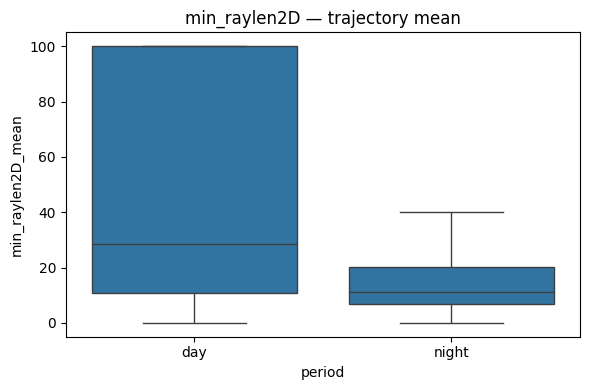

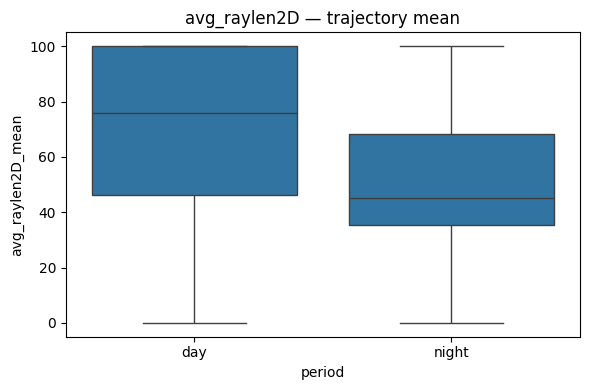

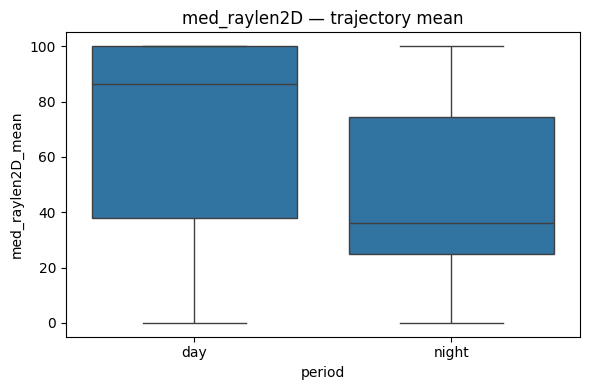

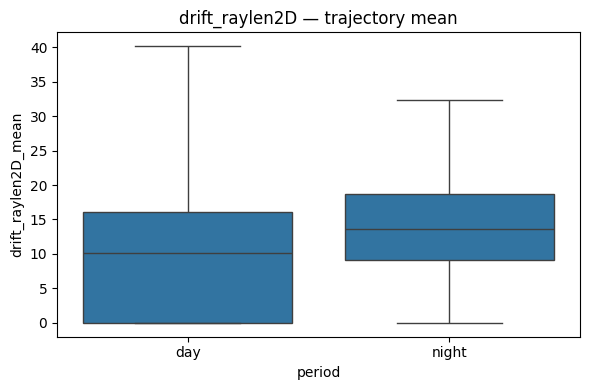

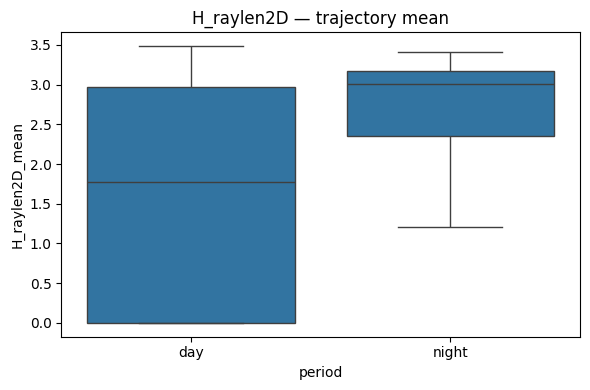

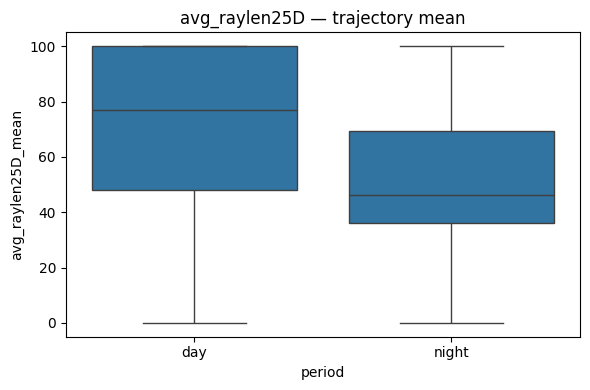

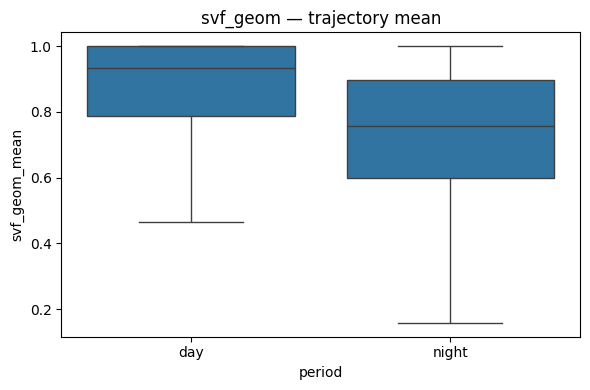

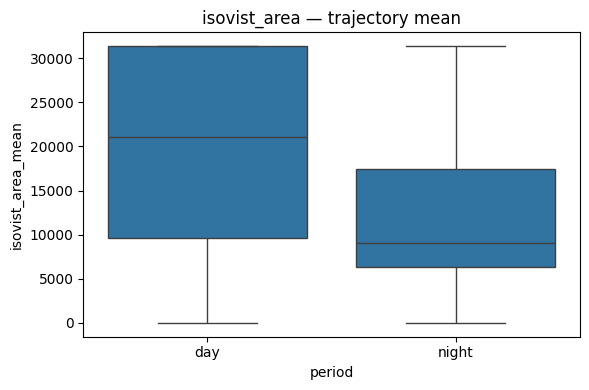

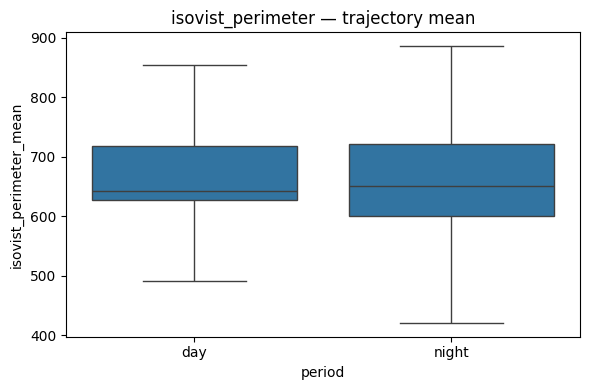

In [10]:
for feature in features:

    col = f"{feature}_mean"

    plt.figure(figsize=(6, 4))

    sns.boxplot(
        data=trajectory_features,
        x="period",
        y=col,
        showfliers=False
    )

    plt.title(f"{feature} — trajectory mean")
    plt.tight_layout()
    plt.show()